# Example for carbon dose calculation using pencilbeam engine.

This example demonstrates how to use the pyRadPlan library to perform carbon ion dose calculations with biological effect modeling.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_carbon.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    load_tg119,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_multiple_slices,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE

logging.basicConfig(level=logging.INFO)

D:\Python\pyRadPlan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a carbon ion therapy plan with biological effect calculation.

In [3]:
# Create a plan object
pln = IonPlan(radiation_mode="carbon", machine="Generic")
pln.prop_stf = {"bixel_width": 4}
pln.prop_dose_calc = {"dose_grid": {"resolution": {"x": 3, "y": 3, "z": 3}}}

pln.prop_opt = {"solver": "scipy"}

In [4]:
# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam: 100%|██████████| 1/1 [00:01<00:00,  1.34s/b]

In [5]:
# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (167,167,108) with resolution x=3.000000, y=3.000000, z=3.000000.


INFO:pyRadPlan.dose.engines._base_pencilbeam_particle:Using a single Gaussian pencil-beam kernel model!



Beam:   0%|          | 0/1 [00:00<?, ?b/s]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Calculating radiological depth cube...
Beam:   0%|          | 0/1 [00:00<?, ?b/s]

...

Ray: 100%|██████████| 496/496 [02:27<00:00,  7.01r/s]

Beam: 100%|██████████| 1/1 [02:28<00:00, 148.96s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.014768 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 150.12 seconds.


In [6]:
# Optimize
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Result
result = dij.compute_result_ct_grid(fluence)

INFO:pyRadPlan.optimization.problems._optiprob:Objective doses are interpreted per fraction (dose_convention='per_fraction').


INFO:pyRadPlan.optimization.problems._optiprob:Legacy objective conversion is enabled; converting physical-dose objectives to quantity: rbe_x_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.cupy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.cupy


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.cupy


...

INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:503 Objective function evaluations, avg. time: 0.0149682 +/- 0.00651541 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:503 Derivative evaluations, avg. time: 0.0341327 +/- 0.00325849 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 27.4481 s


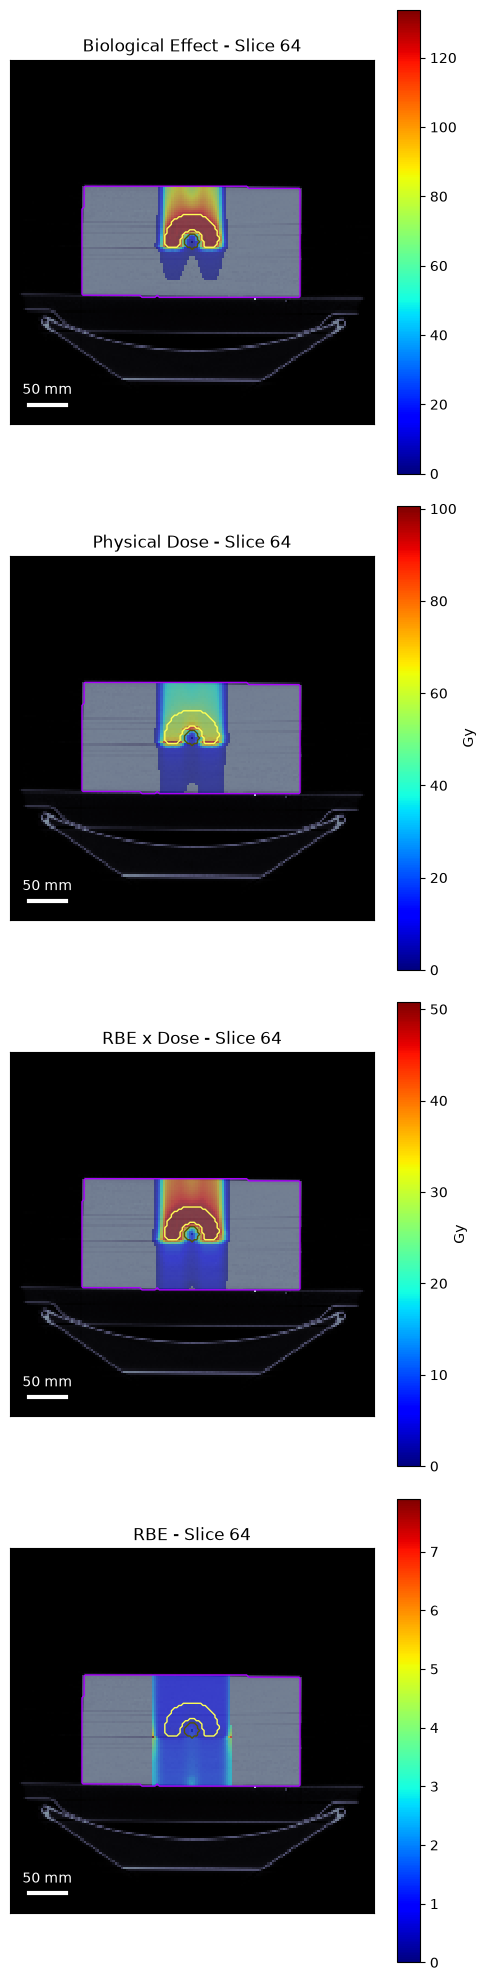

In [7]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose slices to visualize
    view_slice = [int(np.round(ct.size[2] / 2))]

    # Visualize the results
    # Use plot_multiple_slices to visualize the biological effect and physical dose
    # use plot_slice() for single distributions
    plot_multiple_slices(
        image_volume=ct,
        cst=cst,
        overlays=[result["effect"], result["physical_dose"], result["rbe_x_dose"], result["rbe"]],
        view_slice=view_slice,
        plane="axial",
        overlay_unit=["1", "Gy", "Gy", "1"],
        overlay_titles=["Biological Effect", "Physical Dose", "RBE x Dose", "RBE"],
        show_plot=True,
    )